In [89]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [90]:
from google.colab import files
uploaded = files.upload()

Saving dataset.csv to dataset (3).csv


In [91]:
df = pd.read_csv("dataset.csv")

df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [92]:
df.shape

(114000, 21)

In [93]:
df = df.drop(columns=[
    'Unnamed: 0',
    'track_id',
    'album_name',
    'duration_ms',
    'key',
    'mode',
    'time_signature'
])

In [94]:
df = df.dropna()

In [95]:
top_genres = df['track_genre'].value_counts().head(5).index

df = df[df['track_genre'].isin(top_genres)]

df['track_genre'].value_counts()

,count
track_genre,
acoustic,1000
afrobeat,1000
alt-rock,1000
alternative,1000
ambient,1000


In [96]:
features = [
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo'
]

X = df[features]
y = df['track_genre']

In [97]:
le = LabelEncoder()

y = le.fit_transform(y)

In [98]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

In [99]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [100]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=10,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=20, min_samples_split=10, n_estimators=200,
                       random_state=42)

In [101]:
y_pred = rf.predict(X_test)

In [102]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.564


In [103]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.67      0.70      0.68       216
           1       0.68      0.77      0.72       190
           2       0.23      0.25      0.24       192
           3       0.35      0.28      0.31       210
           4       0.88      0.83      0.86       192

    accuracy                           0.56      1000
   macro avg       0.56      0.57      0.56      1000
weighted avg       0.56      0.56      0.56      1000



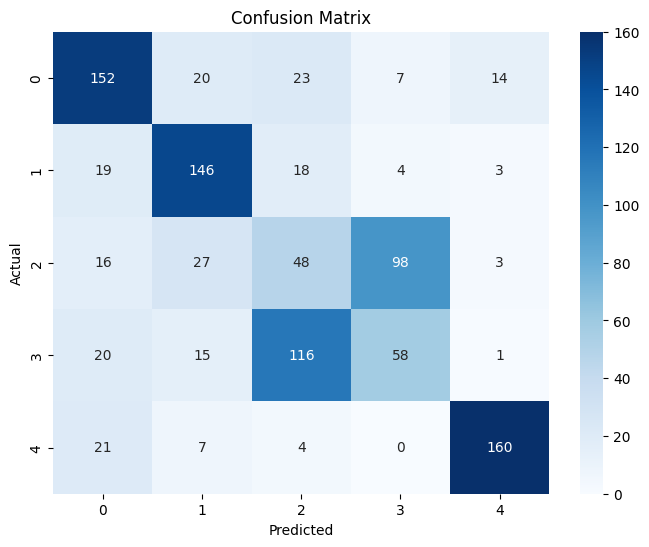

In [104]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [105]:
def recommend_songs(genre):

    songs = df[df['track_genre'] == genre]

    return songs[['track_name','artists','track_genre']].sample(5)

In [107]:
recommend_songs("acoustic")

,track_name,artists,track_genre
213,You And I,Ingrid Michaelson,acoustic
509,Here With Me - Acoustic,Daniel Robinson,acoustic
831,My Babe,Little Walter,acoustic
317,We Don't Talk Anymore / Cold (feat. Sara Phill...,Jonah Baker;Sara Phillips,acoustic
365,アジアの純真,Yosui Inoue;Tamio Okuda,acoustic
